# **ANN 9 – Write a Python program to implement Logistic Regression using TensorFlow/Keras on the Iris dataset.**


In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

In [3]:
def plot_training_history(history):
    """Plots accuracy and loss from the Keras history object."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot training & validation accuracy values
    ax1.plot(history.history['accuracy'])
    ax1.plot(history.history['val_accuracy'])
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='upper left')
    ax1.grid(True)

    # Plot training & validation loss values
    ax2.plot(history.history['loss'])
    ax2.plot(history.history['val_loss'])
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper left')
    ax2.grid(True)
    
    plt.show()

In [4]:
def plot_confusion_matrix(y_true, y_pred, class_names):
    """Plots a confusion matrix using seaborn."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

Training data shape: (120, 4)
Testing data shape: (30, 4)


c:\Users\omshi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15 (60.00 B)

 Trainable params: 15 (60.00 B)

 Non-trainable params: 0 (0.00 B)


--- Starting Model Training ---
Training complete.


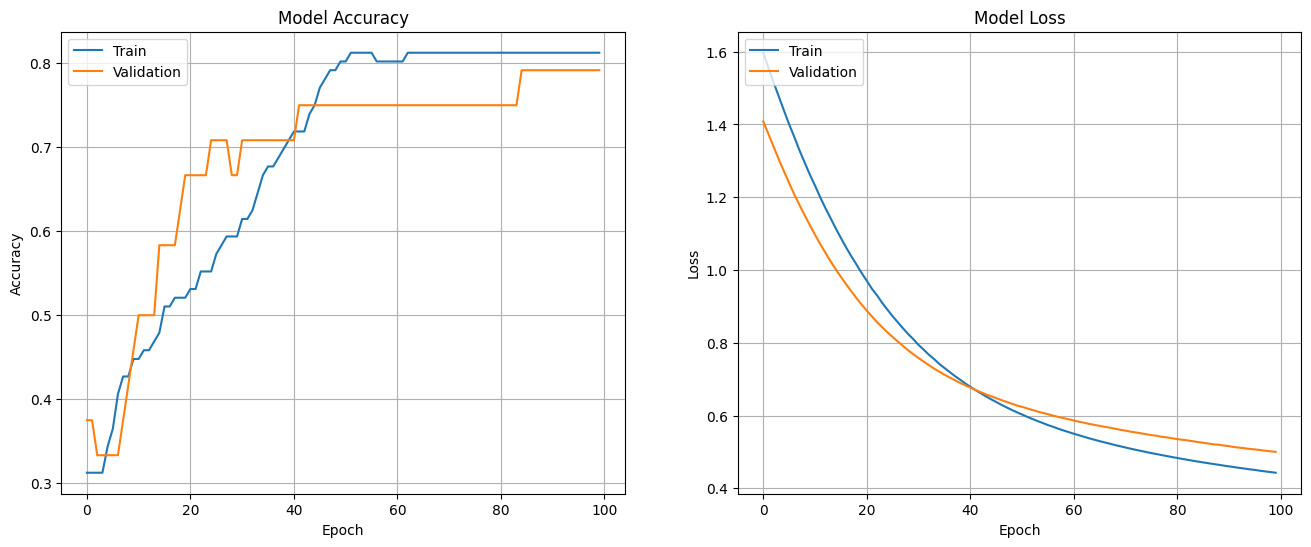


--- Evaluating Model on Test Data ---
Test Accuracy: 0.7667
Test Loss: 0.4911
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


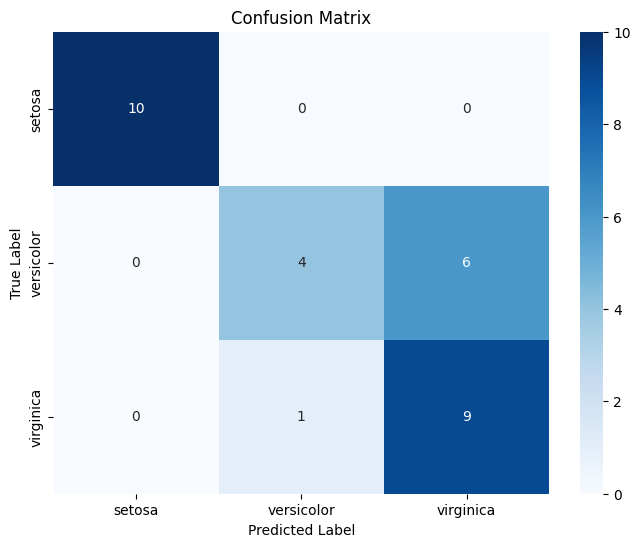

In [5]:
# --- Main execution block ---

if __name__ == "__main__":
    # 1. Load and preprocess the Iris dataset
    iris = load_iris()
    X = iris.data
    y = iris.target
    class_names = iris.target_names

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Scale the features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    print(f"Training data shape: {X_train.shape}")
    print(f"Testing data shape: {X_test.shape}")

    # 2. Define the logistic regression model using TensorFlow/Keras
    # A single Dense layer with softmax is equivalent to logistic regression.
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(3, activation='softmax', input_shape=(4,))
    ])

    # 3. Compile the model
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    
    model.summary()

    # 4. Train the model
    print("\n--- Starting Model Training ---")
    history = model.fit(X_train, y_train, 
                        epochs=100, 
                        batch_size=8, 
                        validation_split=0.2, # Use part of training data for validation
                        verbose=0) # Suppress epoch output for cleaner report
    print("Training complete.")
    
    # 5. Visualize training history
    plot_training_history(history)

    # 6. Evaluate the model on the test set
    print("\n--- Evaluating Model on Test Data ---")
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f'Test Accuracy: {test_acc:.4f}')
    print(f'Test Loss: {test_loss:.4f}')

    # 7. Generate and plot the confusion matrix
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    plot_confusion_matrix(y_test, y_pred, class_names)